# TCN Multi-Output — Paper Configuration (Dudukcu et al. 2023)

**Config**: 1 residual block, 256 filters, batch 128 (Table 2 — ECG TCN row)  
**Strategy**: Multi-Output (MIMO) only  
**Horizons**: 1, 10, 15, 20 steps  
**Patients**: All 21 MIT-BIH (excl. 111 & 118)  
**Training**: 200 epochs, patience 50  

Metrics: RMSE · MAE · R² · Training Time

In [1]:
# ── Install & Imports ────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'wfdb', 'tqdm', 'seaborn', '--quiet'])

import os, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

SEED = 42
np.random.seed(SEED)
print('All imports OK.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00
All imports OK.


In [2]:
# ── TensorFlow Setup ─────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU(s): {[g.name for g in gpus]}')
else:
    print('No GPU — training will be slow.')

GPU(s): ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 1. Configuration — Paper TCN (Table 2)

In [3]:
# ── Dataset path ─────────────────────────────────────────────────────────────
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

# ── Paper constants (Section 3) ──────────────────────────────────────────────
FS           = 360
TOTAL_STEPS  = 100_000
TRAIN_STEPS  = 40_000
VAL_STEPS    = 10_000
TEST_STEPS   = 50_000
LOOKBACK     = 10

# ── All 21 patients (excluding 111 & 118) ───────────────────────────────────
PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21

# ── Forecasting config ───────────────────────────────────────────────────────
HORIZONS      = [1, 10, 15, 20]

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  PAPER CONFIG — Table 2 (ECG, TCN row)                                 │
# │  1 layer (residual block), 256 filters, batch 128                      │
# │  200 epochs, patience 50                                               │
# └──────────────────────────────────────────────────────────────────────────┘
CONFIG_NAME   = 'Paper'
EPOCHS        = 200
PATIENCE      = 50
BATCH_SIZE    = 128       # Table 2: batch 128
NUM_FILTERS   = 256       # Table 2: filter size 256
KERNEL_SIZE   = 3
NUM_BLOCKS    = 1         # Table 2: 1 layer
DROPOUT_RATE  = 0.1
LEARNING_RATE = 1e-3

CSV_NAME      = 'tcn_mo_paper_config_results.csv'
PLOT_DIR      = 'plots_paper'

print(f'Config    : {CONFIG_NAME}')
print(f'Patients  : {len(PATIENTS)}')
print(f'Horizons  : {HORIZONS}')
print(f'Strategy  : Multi-Output only')
print(f'TCN       : filters={NUM_FILTERS}, kernel={KERNEL_SIZE}, blocks={NUM_BLOCKS}')
print(f'Training  : epochs={EPOCHS}, patience={PATIENCE}, batch={BATCH_SIZE}, lr={LEARNING_RATE}')

Config    : Paper
Patients  : 21
Horizons  : [1, 10, 15, 20]
Strategy  : Multi-Output only
TCN       : filters=256, kernel=3, blocks=1
Training  : epochs=200, patience=50, batch=128, lr=0.001


## 2. Data Loading & Preprocessing

In [4]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    """Load MLII lead from MIT-BIH, truncate/pad to n_steps."""
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    """Split → train/val/test, MinMax-normalise (fit on train only)."""
    train_end = train_steps
    val_end   = train_steps + val_steps
    train_raw = signal[:train_end]
    val_raw   = signal[train_end:val_end]
    test_raw  = signal[val_end:]
    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_multistep_sequences(signal, lookback, horizon):
    """X = lookback window, y = next H steps (Multi-Output)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Preprocessing functions defined.')

Preprocessing functions defined.


In [5]:
# ── Load all 21 patients ─────────────────────────────────────────────────────
patient_signals = {}

print(f'Loading {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}
    tqdm.write(f'  Patient {rid:>3s} | train={len(tr):,}  val={len(vl):,}  test={len(te):,}')

print(f'\nAll {len(patient_signals)} patients loaded.')

Loading 21 patients...



Patients:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 | train=40,000  val=10,000  test=50,000
  Patient 101 | train=40,000  val=10,000  test=50,000
  Patient 102 | train=40,000  val=10,000  test=50,000
  Patient 103 | train=40,000  val=10,000  test=50,000
  Patient 104 | train=40,000  val=10,000  test=50,000
  Patient 105 | train=40,000  val=10,000  test=50,000
  Patient 106 | train=40,000  val=10,000  test=50,000
  Patient 107 | train=40,000  val=10,000  test=50,000
  Patient 108 | train=40,000  val=10,000  test=50,000
  Patient 109 | train=40,000  val=10,000  test=50,000
  Patient 112 | train=40,000  val=10,000  test=50,000
  Patient 113 | train=40,000  val=10,000  test=50,000
  Patient 114 | train=40,000  val=10,000  test=50,000
  Patient 115 | train=40,000  val=10,000  test=50,000
  Patient 116 | train=40,000  val=10,000  test=50,000
  Patient 117 | train=40,000  val=10,000  test=50,000
  Patient 119 | train=40,000  val=10,000  test=50,000
  Patient 121 | train=40,000  val=10,000  test=50,000
  Patient 122 | train=40,000

## 3. TCN Architecture

In [6]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    return Add()([x, out])


def build_tcn(lookback, output_size):
    inp = Input(shape=(lookback, 1))
    x = inp
    for i in range(NUM_BLOCKS):
        x = residual_block(x, NUM_FILTERS, KERNEL_SIZE, 2 ** i, DROPOUT_RATE)
    x = x[:, -1, :]  # last time-step
    x = Dense(NUM_FILTERS, activation='relu')(x)
    out = Dense(output_size)(x)
    model = Model(inp, out, name=f'TCN_out{output_size}')
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss='mse')
    return model


def train_tcn(model, X_train, y_train, X_val, y_val):
    X_tr = X_train.reshape(-1, X_train.shape[1], 1)
    X_vl = X_val.reshape(-1, X_val.shape[1], 1)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=max(PATIENCE // 2, 2), min_lr=1e-6),
    ]
    history = model.fit(
        X_tr, y_train, validation_data=(X_vl, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=0
    )
    return history


# Show architecture for H=1
_sample = build_tcn(LOOKBACK, 1)
_sample.summary()
del _sample
tf.keras.backend.clear_session()

I0000 00:00:1786294406.096762      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786294406.099782      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "TCN_out1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 256)   │      1,024 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 256)   │      1,024 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 256)   │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 256)   │    196,864 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 256)   │      1,024 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 256)   │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 256)   │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 256)   │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 256)       │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 266,497 (1.02 MB)

 Trainable params: 265,473 (1.01 MB)

 Non-trainable params: 1,024 (4.00 KB)

## 4. Metrics

In [7]:
def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


def compute_per_step_metrics(y_true, y_pred):
    rows = []
    for h in range(y_true.shape[1]):
        m = compute_metrics(y_true[:, h], y_pred[:, h])
        m['Step'] = h + 1
        rows.append(m)
    return pd.DataFrame(rows)


print('Metrics functions defined.')

Metrics functions defined.


## 5. Training Loop — Multi-Output, All 21 Patients × 4 Horizons

In [8]:
results          = []
per_step_results = {}
saved_preds      = {}
training_histories = {}

os.makedirs(PLOT_DIR, exist_ok=True)

total_runs = len(PATIENTS) * len(HORIZONS)
print(f'Config: {CONFIG_NAME}')
print(f'Running: {len(PATIENTS)} patients × {len(HORIZONS)} horizons = {total_runs} models')
print(f'TCN: {NUM_BLOCKS} block(s), {NUM_FILTERS} filters, batch {BATCH_SIZE}')
print(f'Training: {EPOCHS} epochs, patience {PATIENCE}')
print('=' * 80)

for rid in tqdm(PATIENTS, desc='Patients'):
    tr = patient_signals[rid]['train']
    vl = patient_signals[rid]['val']
    te = patient_signals[rid]['test']

    for horizon in HORIZONS:
        X_tr, y_tr = make_multistep_sequences(tr, LOOKBACK, horizon)
        X_vl, y_vl = make_multistep_sequences(vl, LOOKBACK, horizon)
        X_te, y_te = make_multistep_sequences(te, LOOKBACK, horizon)

        t0 = time.time()
        model = build_tcn(LOOKBACK, horizon)
        history = train_tcn(model, X_tr, y_tr, X_vl, y_vl)
        preds = model.predict(
            X_te.reshape(-1, X_te.shape[1], 1),
            batch_size=2048, verbose=0
        )
        elapsed = time.time() - t0

        m = compute_metrics(y_te, preds)
        m['Time_s'] = round(elapsed, 2)
        results.append({'Patient': rid, 'Horizon': horizon, **m})

        if horizon > 1:
            per_step_results[(rid, horizon)] = compute_per_step_metrics(y_te, preds)

        saved_preds[(rid, horizon)] = (y_te.copy(), preds.copy())
        training_histories[(rid, horizon)] = {
            'loss': history.history['loss'],
            'val_loss': history.history['val_loss'],
        }

        del model
        gc.collect()

        tqdm.write(
            f'  Patient {rid} H={horizon:2d} | '
            f'R²={m["R2"]:.4f}  RMSE={m["RMSE"]:.4f}  MAE={m["MAE"]:.4f}  '
            f'({elapsed:.1f}s)'
        )

    tf.keras.backend.clear_session()
    gc.collect()

print(f'\nAll {len(results)} experiments complete.')

Config: Paper
Running: 21 patients × 4 horizons = 84 models
TCN: 1 block(s), 256 filters, batch 128
Training: 200 epochs, patience 50


Patients:   0%|          | 0/21 [00:00<?, ?it/s]

I0000 00:00:1786294414.106336      79 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Patient 100 H= 1 | R²=0.9957  RMSE=0.0063  MAE=0.0046  (211.6s)
  Patient 100 H=10 | R²=0.9041  RMSE=0.0298  MAE=0.0126  (246.8s)
  Patient 100 H=15 | R²=0.7886  RMSE=0.0442  MAE=0.0172  (168.1s)
  Patient 100 H=20 | R²=0.6284  RMSE=0.0586  MAE=0.0232  (145.0s)
  Patient 101 H= 1 | R²=0.9558  RMSE=0.0231  MAE=0.0051  (214.8s)
  Patient 101 H=10 | R²=0.6343  RMSE=0.0665  MAE=0.0192  (100.6s)
  Patient 101 H=15 | R²=0.6717  RMSE=0.0630  MAE=0.0229  (122.2s)
  Patient 101 H=20 | R²=0.6510  RMSE=0.0649  MAE=0.0242  (93.0s)
  Patient 102 H= 1 | R²=0.9953  RMSE=0.0047  MAE=0.0035  (245.2s)
  Patient 102 H=10 | R²=0.7992  RMSE=0.0303  MAE=0.0125  (214.2s)
  Patient 102 H=15 | R²=0.6836  RMSE=0.0380  MAE=0.0171  (142.1s)
  Patient 102 H=20 | R²=0.6173  RMSE=0.0418  MAE=0.0192  (164.7s)
  Patient 103 H= 1 | R²=0.9983  RMSE=0.0048  MAE=0.0036  (250.1s)
  Patient 103 H=10 | R²=0.9294  RMSE=0.0308  MAE=0.0121  (190.5s)
  Patient 103 H=15 | R²=0.8180  RMSE=0.0495  MAE=0.0173  (248.0s)
  Patient 1

## 6. Results Summary

In [9]:
df_results = pd.DataFrame(results)
df_results.to_csv(CSV_NAME, index=False)
print(f'Results saved → {CSV_NAME}\n')

df_avg = (
    df_results
    .groupby('Horizon')
    .agg(
        RMSE_mean=('RMSE', 'mean'), RMSE_std=('RMSE', 'std'),
        MAE_mean=('MAE', 'mean'),   MAE_std=('MAE', 'std'),
        R2_mean=('R2', 'mean'),     R2_std=('R2', 'std'),
        Time_mean=('Time_s', 'mean'),
    )
    .round(4)
)
print(f'Average Results — {CONFIG_NAME} Config (21 Patients, Multi-Output)')
print('=' * 70)
display(df_avg)

for h in HORIZONS:
    print(f'\n{"─"*30} Horizon {h} {"─"*30}')
    df_h = df_results[df_results['Horizon'] == h]
    display(df_h[['Patient', 'RMSE', 'MAE', 'R2', 'Time_s']].set_index('Patient').round(4))

Results saved → tcn_mo_paper_config_results.csv

Average Results — Paper Config (21 Patients, Multi-Output)


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,Time_mean
Horizon,,,,,,,
1,0.0061,0.0044,0.0037,0.0013,0.9952,0.0093,226.6267
10,0.0344,0.0112,0.0148,0.0052,0.8776,0.0883,207.6795
15,0.0471,0.0106,0.0200,0.0059,0.7847,0.1002,202.0495
20,0.0571,0.0111,0.0253,0.0067,0.6894,0.1146,188.6010



────────────────────────────── Horizon 1 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0063,0.0046,0.9957,211.60
101,0.0231,0.0051,0.9558,214.77
102,0.0047,0.0035,0.9953,245.19
103,0.0048,0.0036,0.9983,250.05
104,0.0099,0.0065,0.9909,169.29
105,0.0053,0.0040,0.9979,247.51
106,0.0045,0.0034,0.9976,253.80
107,0.0033,0.0024,0.9994,251.44
108,0.0086,0.0062,0.9909,251.79



────────────────────────────── Horizon 10 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0298,0.0126,0.9041,246.81
101,0.0665,0.0192,0.6343,100.58
102,0.0303,0.0125,0.7992,214.21
103,0.0308,0.0121,0.9294,190.52
104,0.0532,0.0295,0.7397,98.68
105,0.0409,0.0174,0.8741,241.53
106,0.0397,0.0144,0.8189,231.07
107,0.0344,0.0153,0.9318,250.35
108,0.0459,0.0242,0.7443,121.71



────────────────────────────── Horizon 15 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0442,0.0172,0.7886,168.06
101,0.0630,0.0229,0.6717,122.18
102,0.0380,0.0171,0.6836,142.10
103,0.0495,0.0173,0.8180,248.03
104,0.0630,0.0348,0.6339,130.48
105,0.0615,0.0261,0.7158,192.21
106,0.0528,0.0209,0.6800,170.70
107,0.0450,0.0209,0.8831,134.21
108,0.0553,0.0287,0.6283,156.71



────────────────────────────── Horizon 20 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0586,0.0232,0.6284,145.00
101,0.0649,0.0242,0.6510,92.96
102,0.0418,0.0192,0.6173,164.73
103,0.0686,0.0246,0.6499,237.19
104,0.0689,0.0393,0.5621,120.62
105,0.0733,0.0341,0.5954,201.36
106,0.0603,0.0282,0.5832,114.86
107,0.0515,0.0266,0.8472,220.02
108,0.0616,0.0326,0.5392,113.91


---

## 7. Visualizations

### 7.1 — R² Heatmap: Patients × Horizons

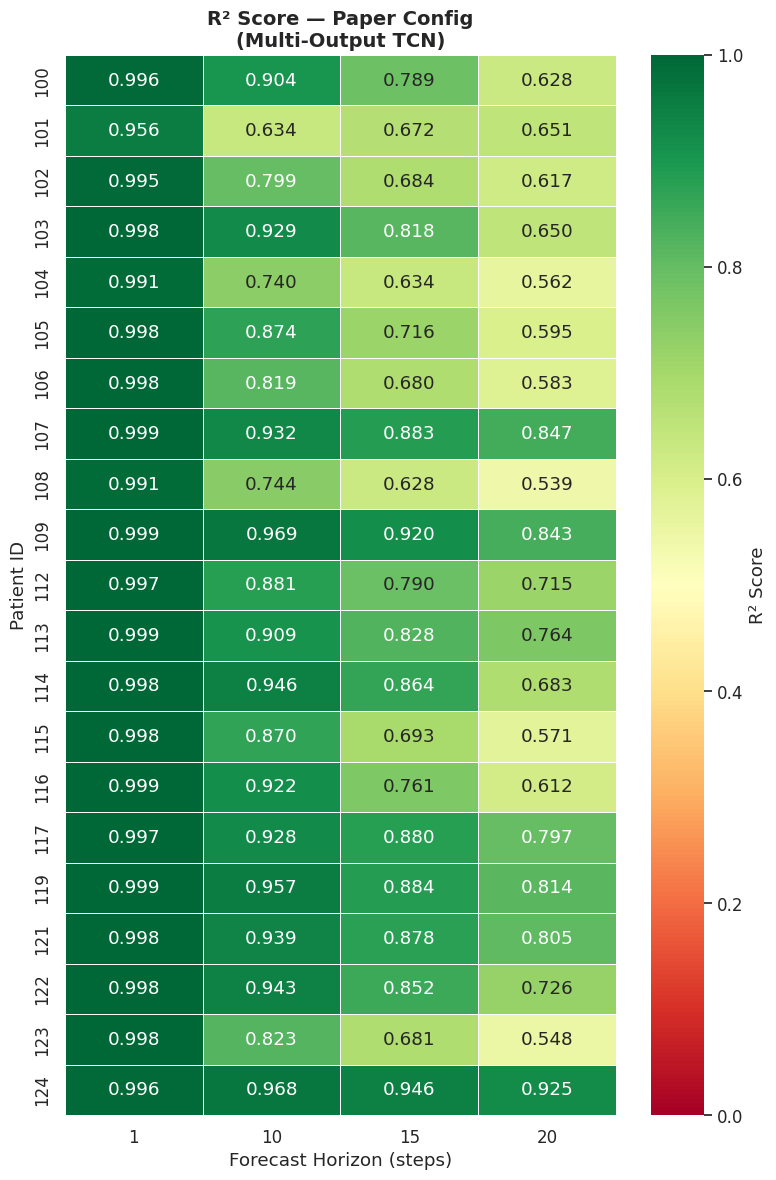

In [10]:
pivot_r2 = df_results.pivot(index='Patient', columns='Horizon', values='R2')

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={'label': 'R² Score'}
)
ax.set_title(f'R² Score — {CONFIG_NAME} Config\n(Multi-Output TCN)', fontsize=14, fontweight='bold')
ax.set_ylabel('Patient ID')
ax.set_xlabel('Forecast Horizon (steps)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/heatmap_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 — RMSE Heatmap

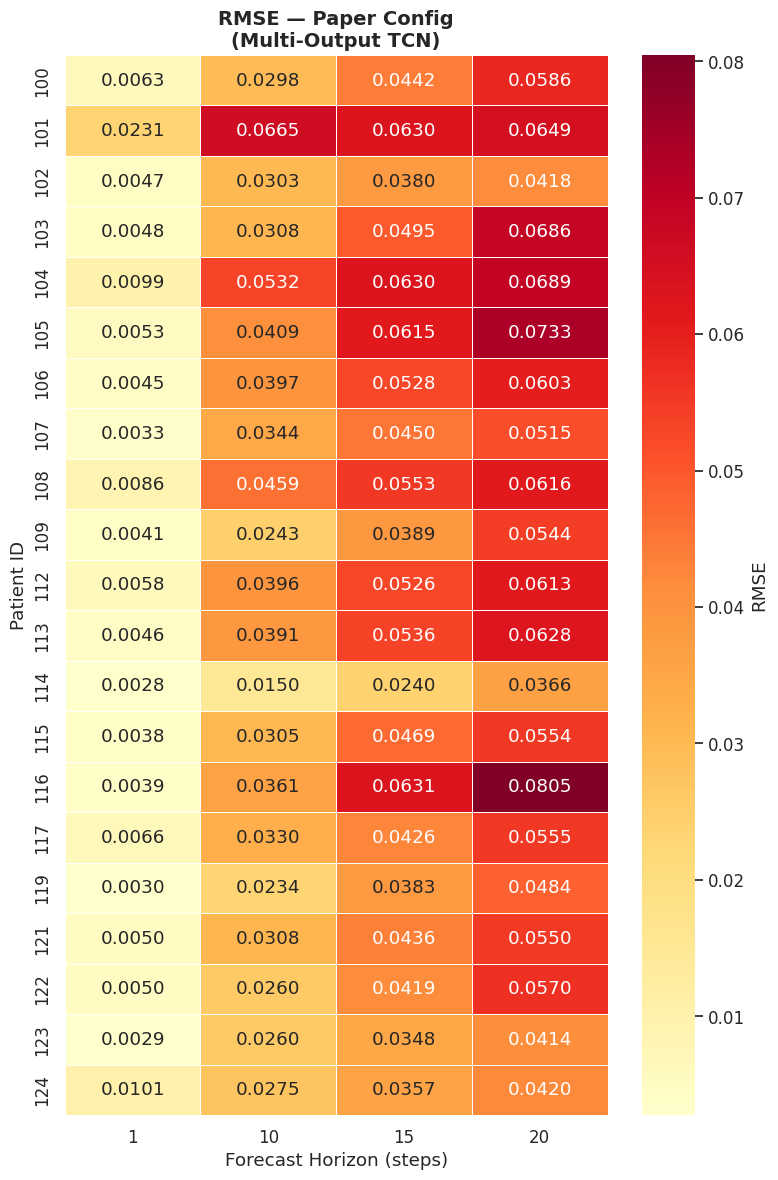

In [11]:
pivot_rmse = df_results.pivot(index='Patient', columns='Horizon', values='RMSE')

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    pivot_rmse, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'RMSE'}
)
ax.set_title(f'RMSE — {CONFIG_NAME} Config\n(Multi-Output TCN)', fontsize=14, fontweight='bold')
ax.set_ylabel('Patient ID')
ax.set_xlabel('Forecast Horizon (steps)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/heatmap_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 — Box Plots: Metric Distributions per Horizon

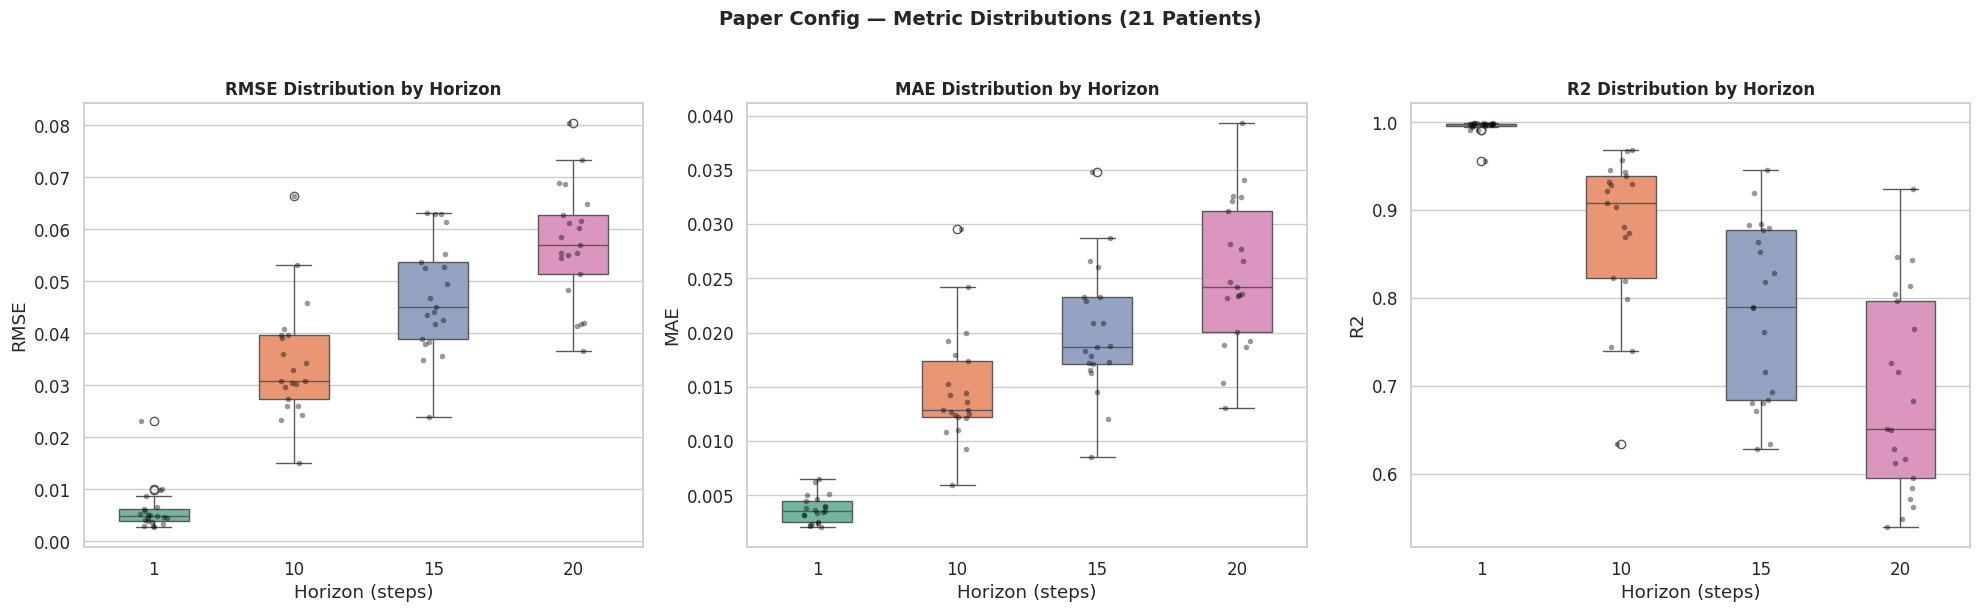

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    sns.boxplot(data=df_results, x='Horizon', y=metric, ax=ax, palette='Set2', width=0.5)
    sns.stripplot(data=df_results, x='Horizon', y=metric, ax=ax,
                  color='black', alpha=0.4, size=4, jitter=True)
    ax.set_title(f'{metric} Distribution by Horizon', fontsize=12, fontweight='bold')
    ax.set_xlabel('Horizon (steps)')
    ax.set_ylabel(metric)

fig.suptitle(f'{CONFIG_NAME} Config — Metric Distributions (21 Patients)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/boxplots_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 — Bar Chart: Mean Metrics by Horizon (with error bars)

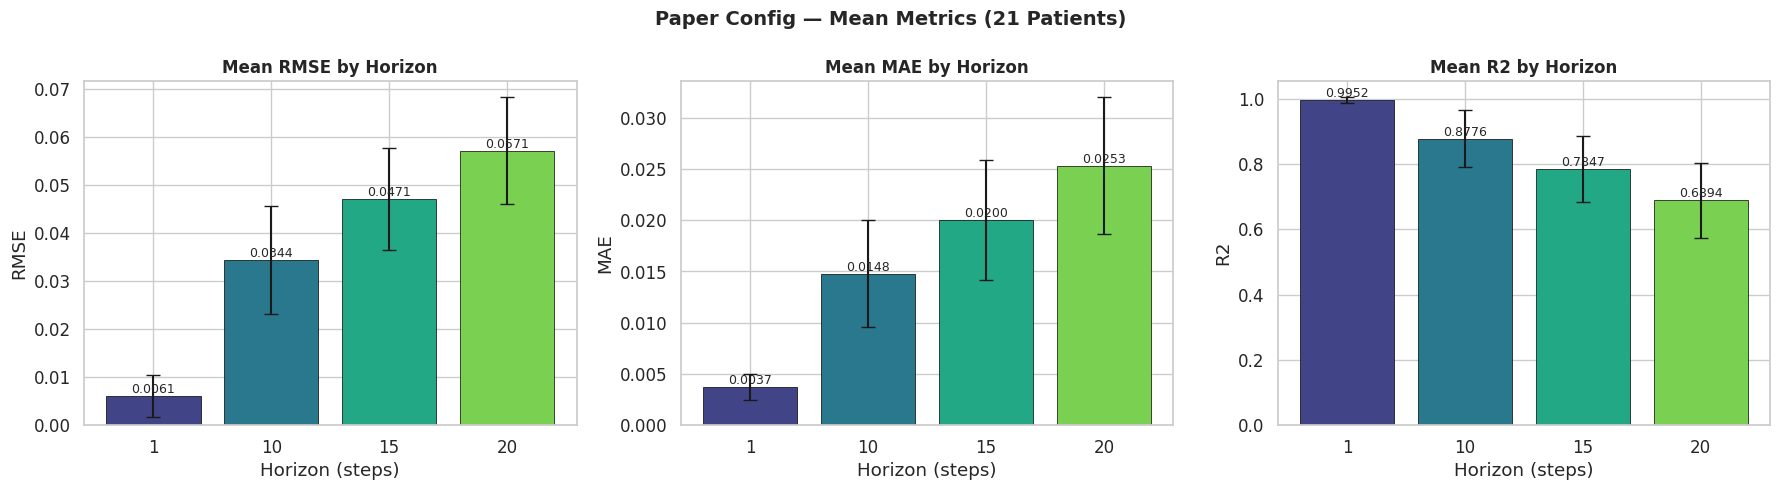

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    means = df_results.groupby('Horizon')[metric].mean()
    stds  = df_results.groupby('Horizon')[metric].std()
    colors = sns.color_palette('viridis', len(HORIZONS))

    bars = ax.bar(range(len(HORIZONS)), means.values, yerr=stds.values,
                  capsize=5, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels([str(h) for h in HORIZONS])
    ax.set_title(f'Mean {metric} by Horizon', fontsize=12, fontweight='bold')
    ax.set_xlabel('Horizon (steps)')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(f'{CONFIG_NAME} Config — Mean Metrics (21 Patients)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/barchart_mean_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 — Per-Step RMSE Degradation

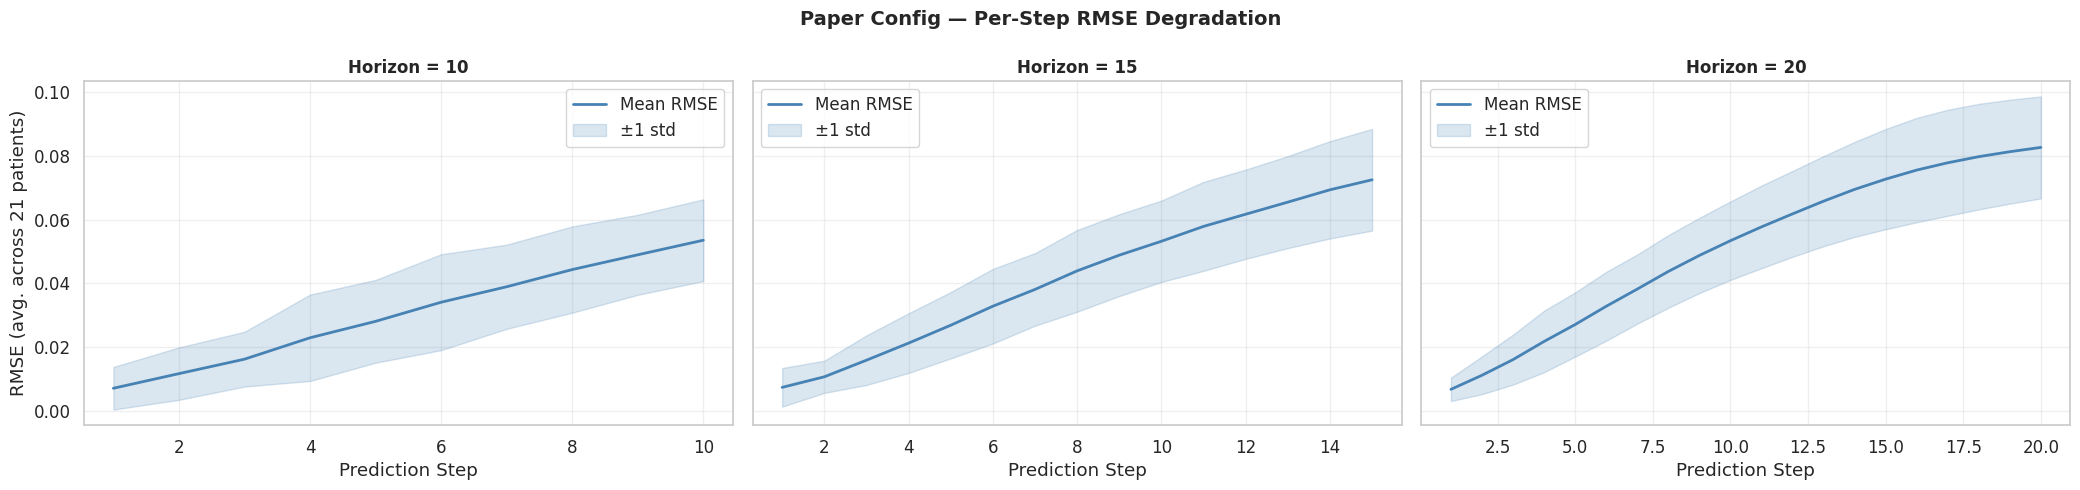

In [14]:
multi_step_horizons = [h for h in HORIZONS if h > 1]
fig, axes = plt.subplots(1, len(multi_step_horizons),
                         figsize=(7 * len(multi_step_horizons), 5), sharey=True)
if len(multi_step_horizons) == 1:
    axes = [axes]

for idx, horizon in enumerate(multi_step_horizons):
    ax = axes[idx]
    step_dfs = [per_step_results[(rid, horizon)]
                for rid in PATIENTS if (rid, horizon) in per_step_results]
    if not step_dfs:
        continue
    combined = pd.concat(step_dfs)
    avg_by_step = combined.groupby('Step')['RMSE'].mean()
    std_by_step = combined.groupby('Step')['RMSE'].std()

    ax.plot(avg_by_step.index, avg_by_step.values, linewidth=2, color='steelblue', label='Mean RMSE')
    ax.fill_between(avg_by_step.index,
                    avg_by_step.values - std_by_step.values,
                    avg_by_step.values + std_by_step.values,
                    alpha=0.2, color='steelblue', label='±1 std')
    ax.set_title(f'Horizon = {horizon}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediction Step')
    if idx == 0:
        ax.set_ylabel('RMSE (avg. across 21 patients)')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(f'{CONFIG_NAME} Config — Per-Step RMSE Degradation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 — Per-Step R² Degradation (all horizons overlaid)

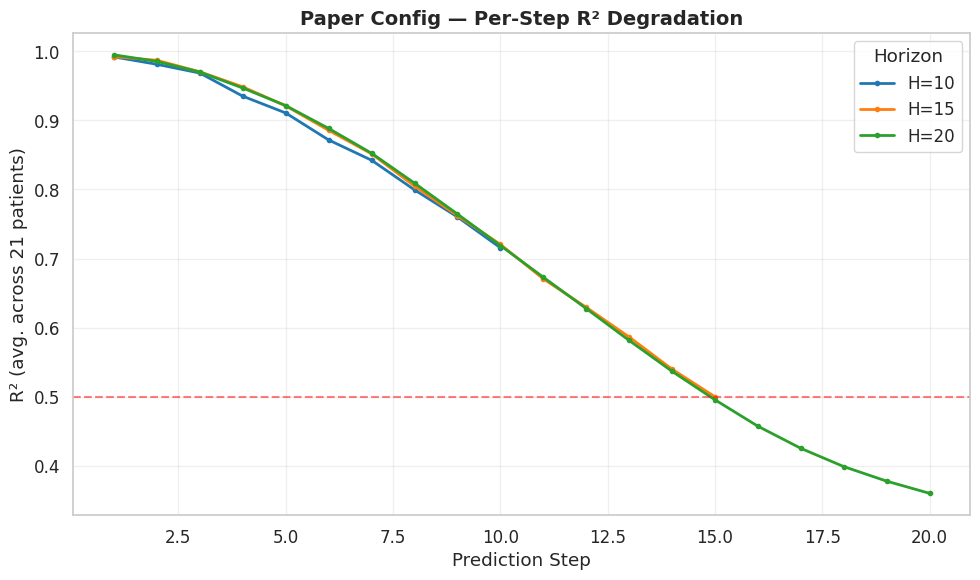

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('tab10', len(multi_step_horizons))

for idx, horizon in enumerate(multi_step_horizons):
    step_dfs = [per_step_results[(rid, horizon)]
                for rid in PATIENTS if (rid, horizon) in per_step_results]
    if not step_dfs:
        continue
    combined = pd.concat(step_dfs)
    avg_r2 = combined.groupby('Step')['R2'].mean()
    ax.plot(avg_r2.index, avg_r2.values, linewidth=2, color=colors[idx],
            marker='o', markersize=3, label=f'H={horizon}')

ax.set_title(f'{CONFIG_NAME} Config — Per-Step R² Degradation', fontsize=14, fontweight='bold')
ax.set_xlabel('Prediction Step')
ax.set_ylabel('R² (avg. across 21 patients)')
ax.legend(title='Horizon')
ax.grid(alpha=0.3)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_r2_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.7 — Actual vs Predicted (Representative Patients)

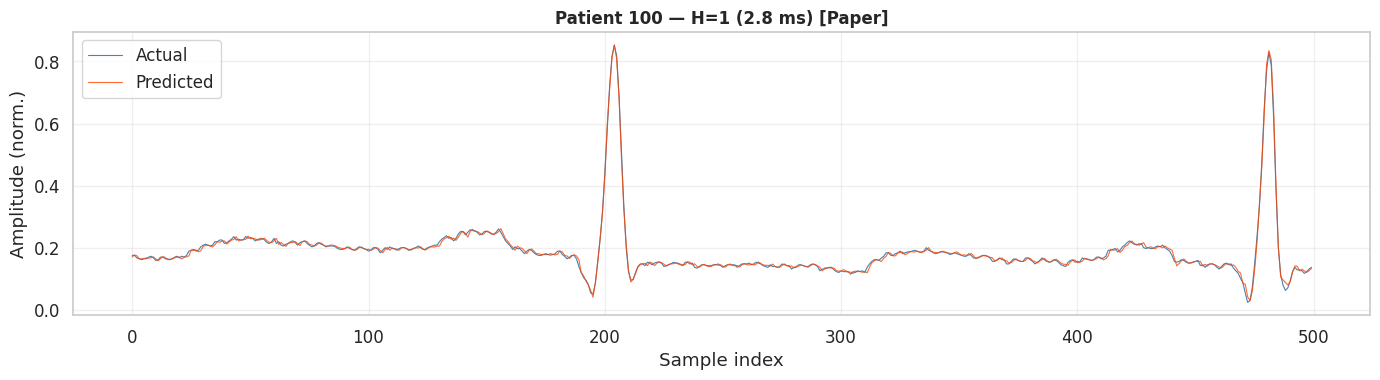

  Saved: plots_paper/pred_100_MO_H1.png


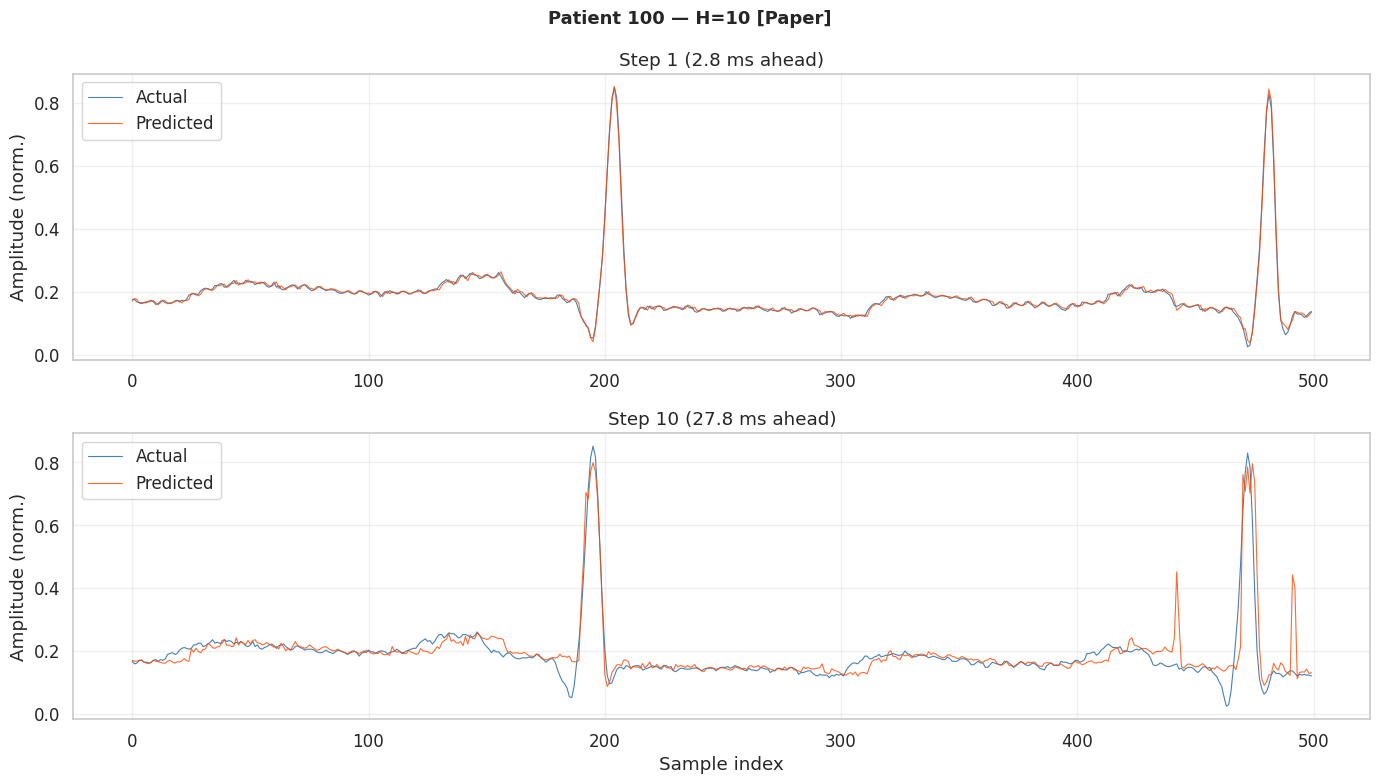

  Saved: plots_paper/pred_100_MO_H10.png


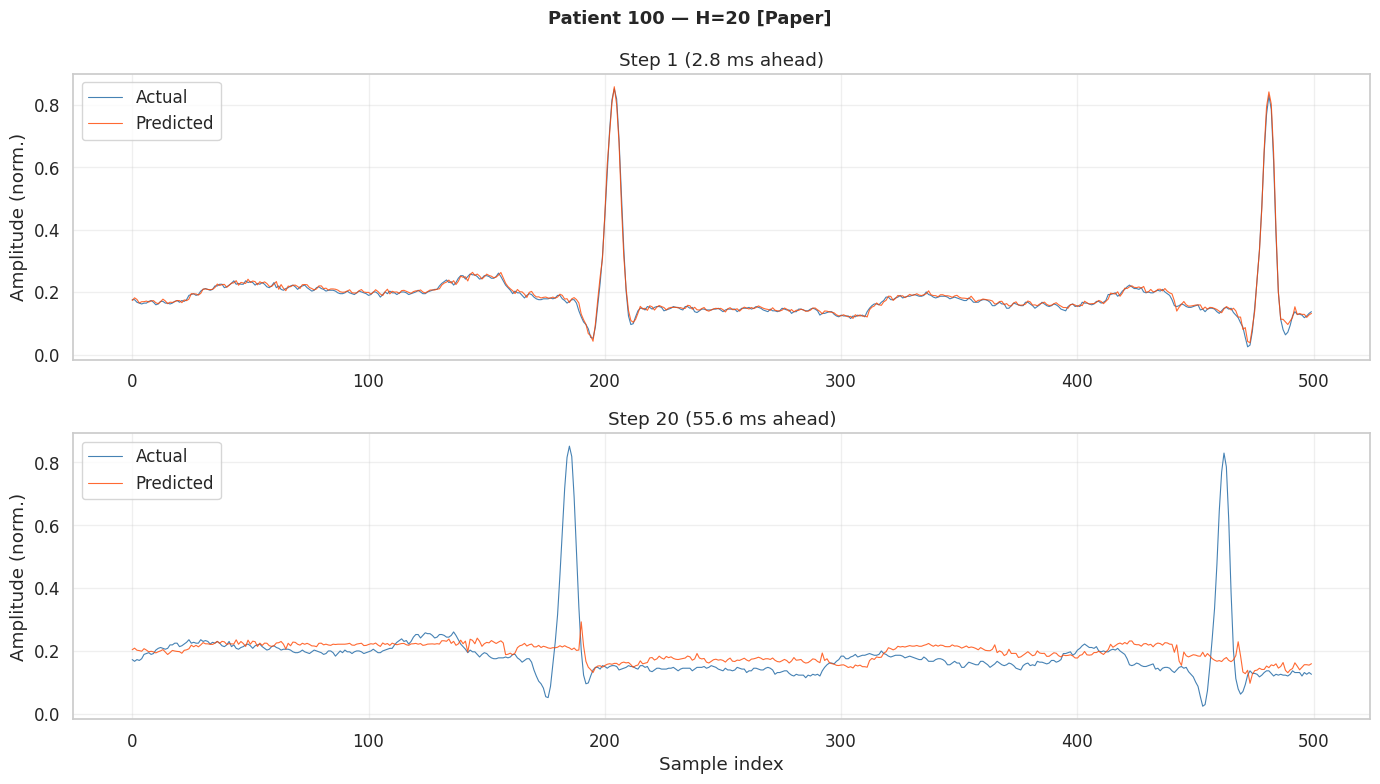

  Saved: plots_paper/pred_100_MO_H20.png


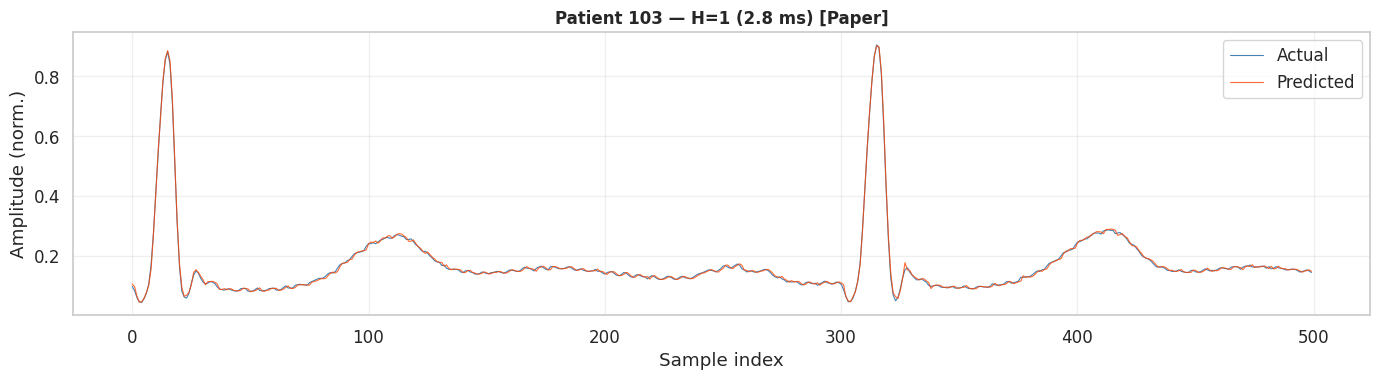

  Saved: plots_paper/pred_103_MO_H1.png


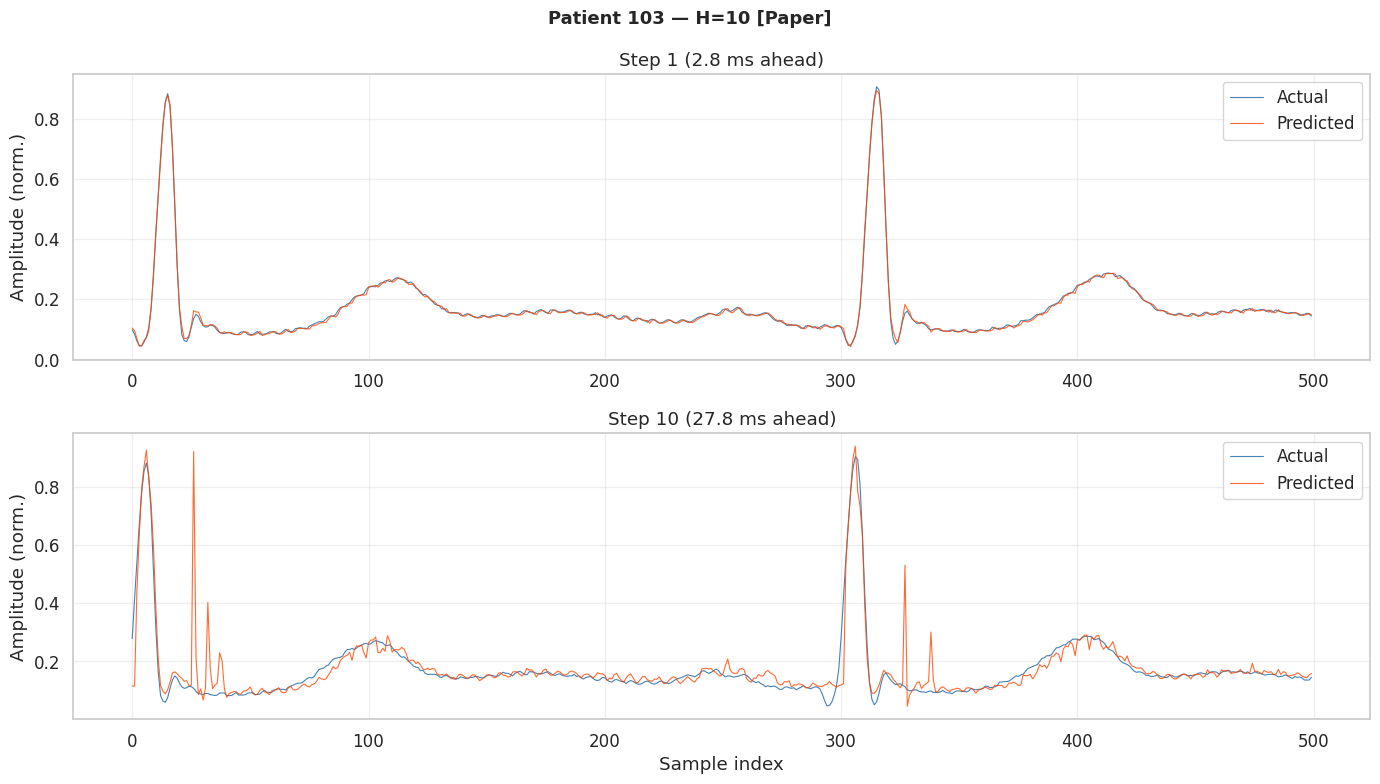

  Saved: plots_paper/pred_103_MO_H10.png


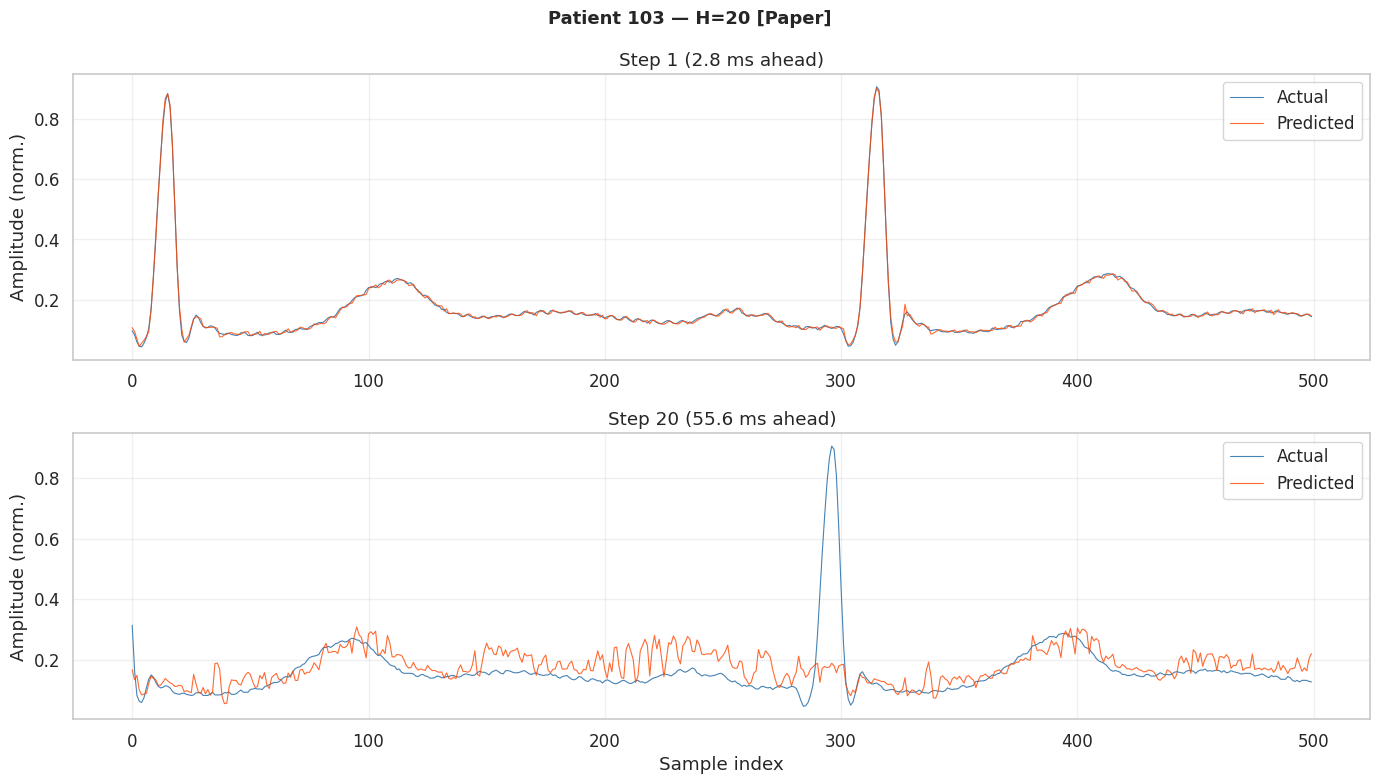

  Saved: plots_paper/pred_103_MO_H20.png


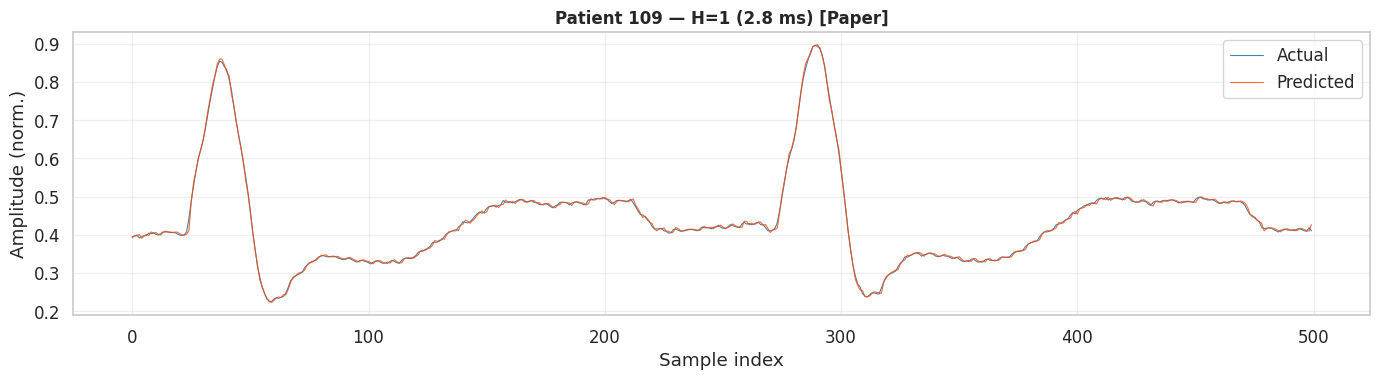

  Saved: plots_paper/pred_109_MO_H1.png


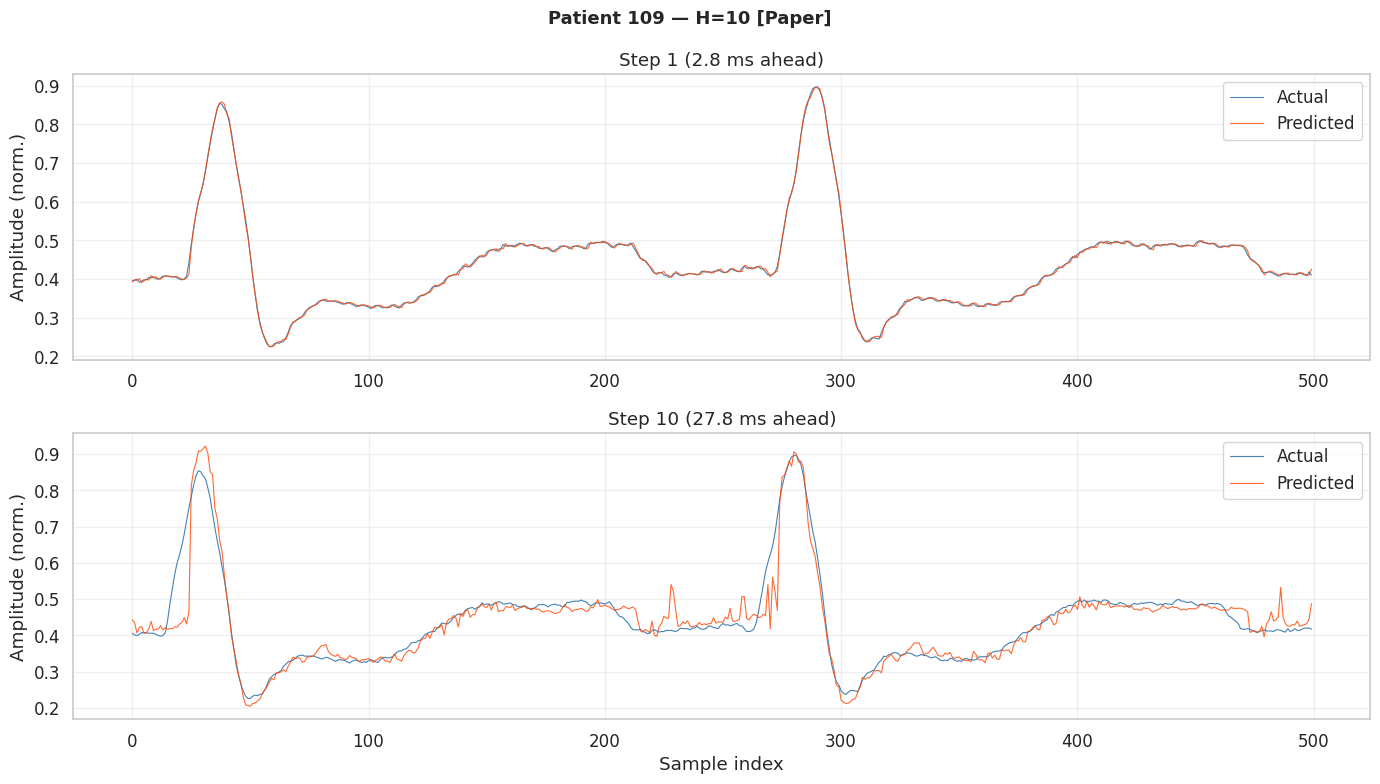

  Saved: plots_paper/pred_109_MO_H10.png


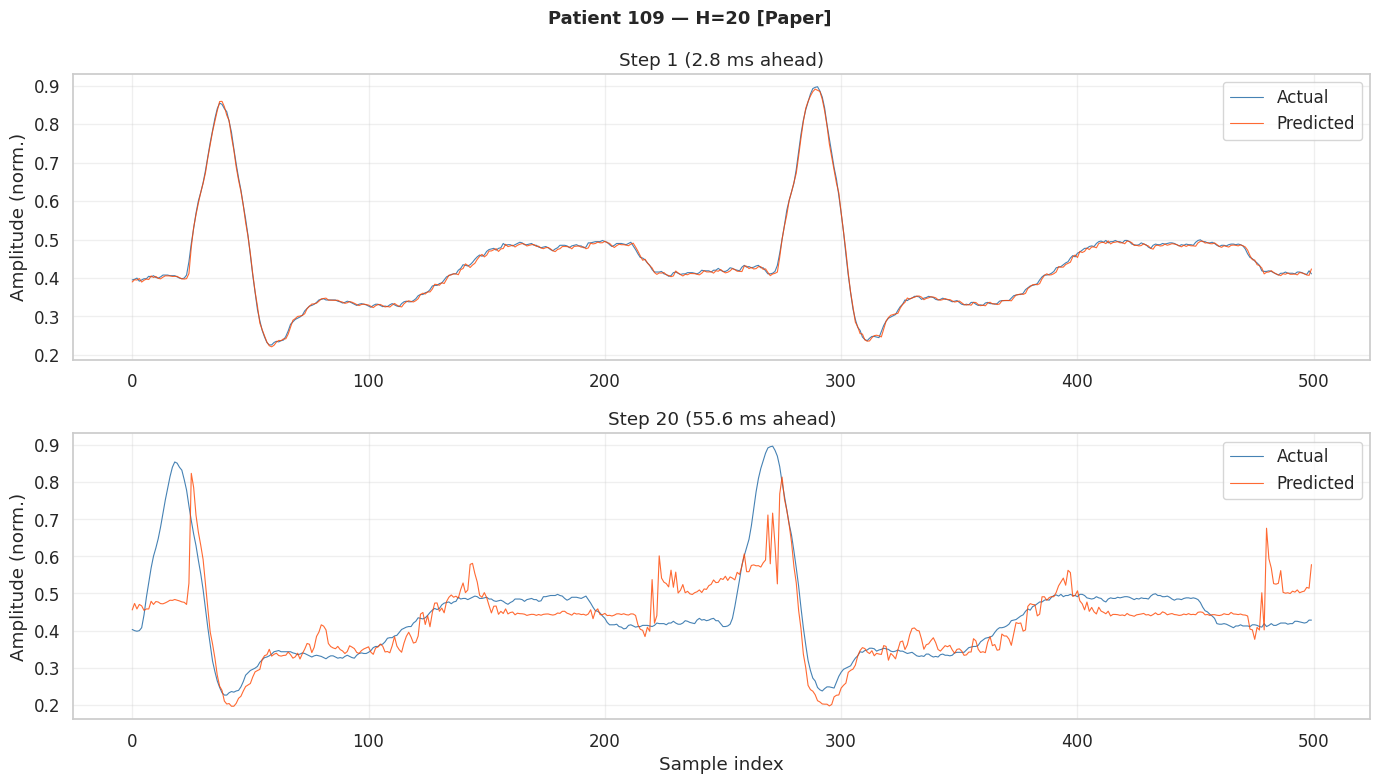

  Saved: plots_paper/pred_109_MO_H20.png


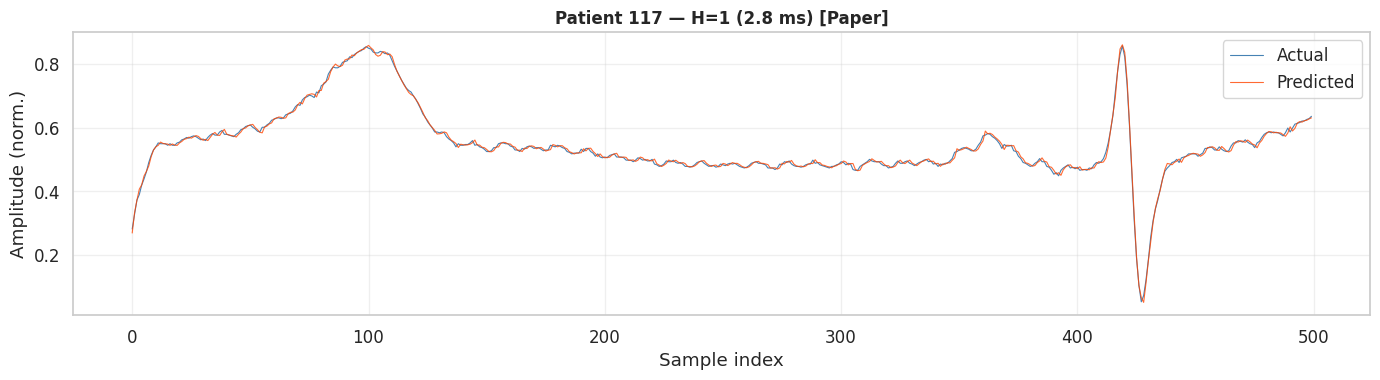

  Saved: plots_paper/pred_117_MO_H1.png


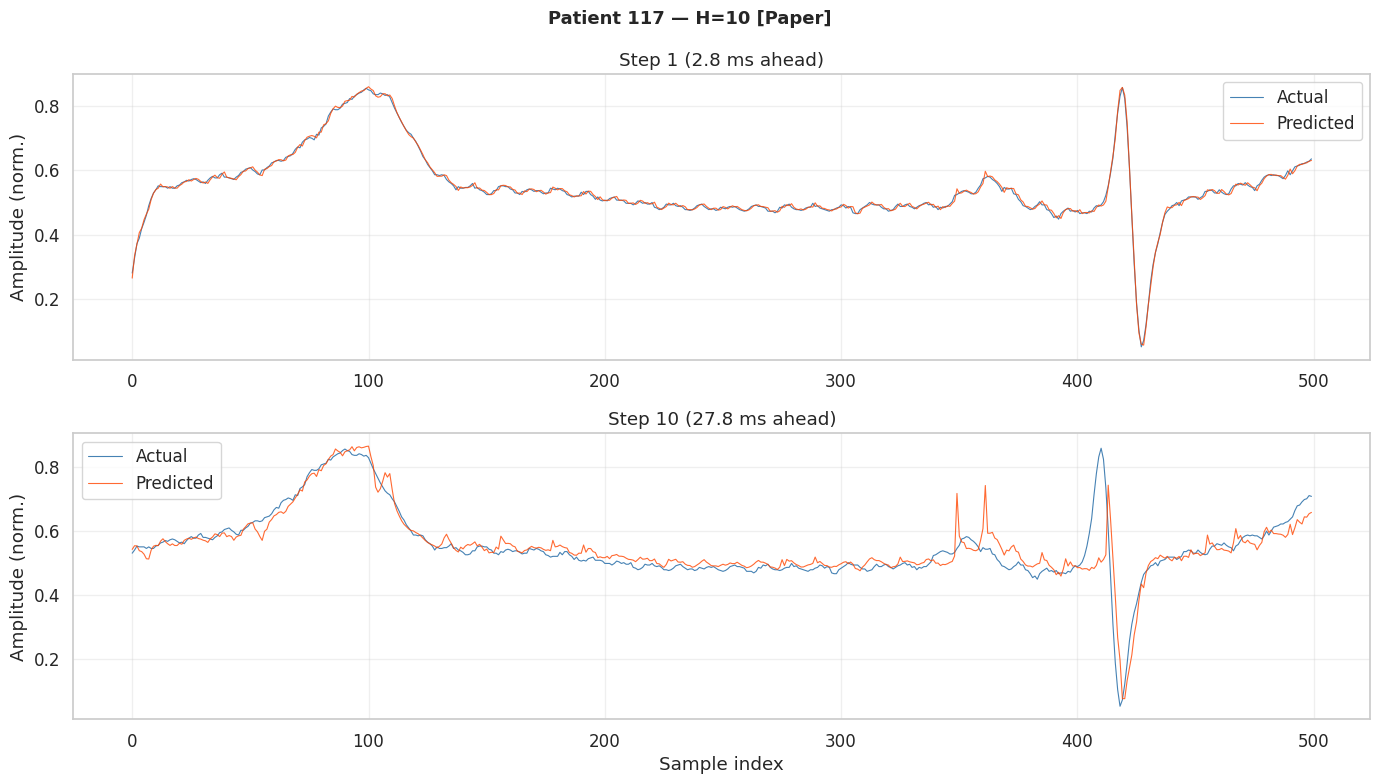

  Saved: plots_paper/pred_117_MO_H10.png


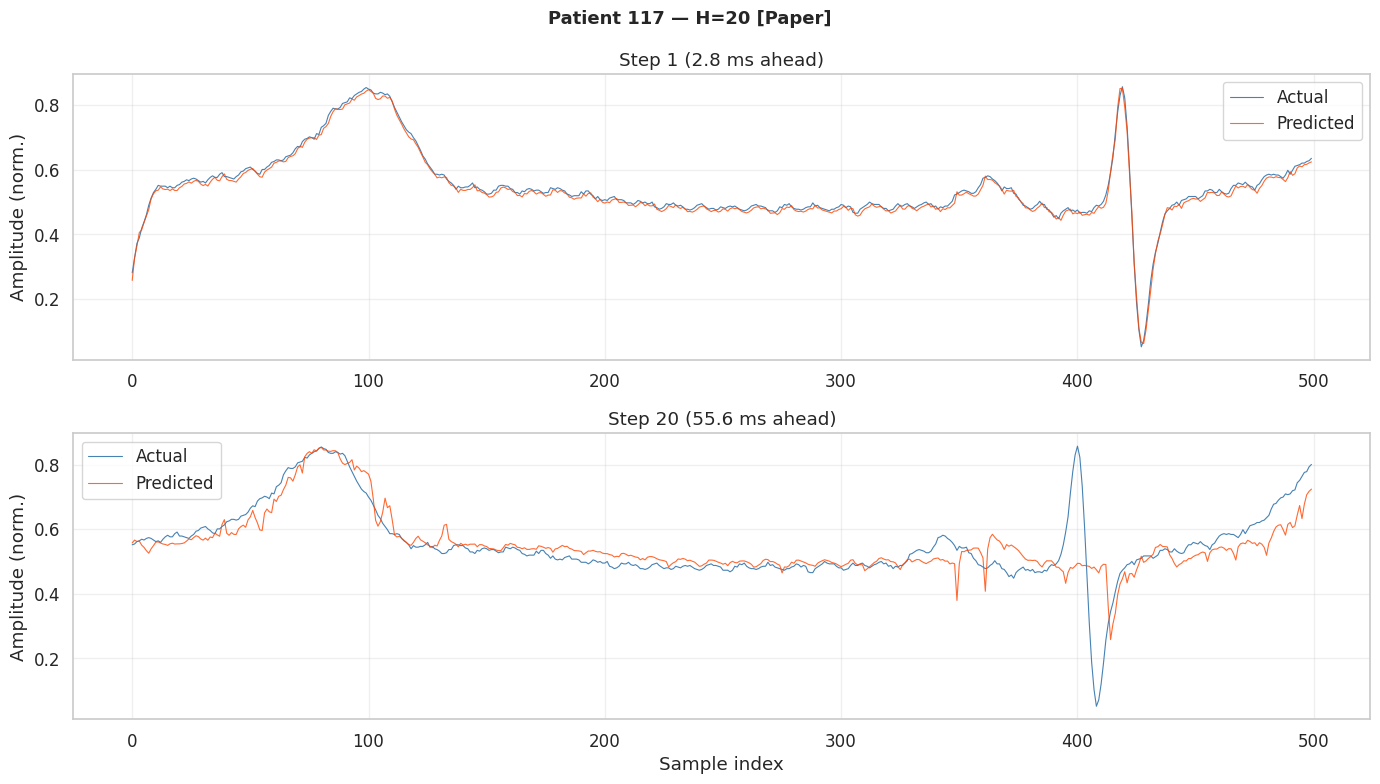

  Saved: plots_paper/pred_117_MO_H20.png


In [16]:
VIZ_PATIENTS = ['100', '103', '109', '117']
VIZ_HORIZONS = [1, 10, 20]

for rid in VIZ_PATIENTS:
    for horizon in VIZ_HORIZONS:
        key = (rid, horizon)
        if key not in saved_preds:
            continue
        y_te, preds = saved_preds[key]
        n_show = min(500, len(y_te))

        if horizon == 1:
            fig, ax = plt.subplots(figsize=(14, 4))
            ax.plot(y_te[:n_show].flatten(), label='Actual', linewidth=0.8, color='steelblue')
            ax.plot(preds[:n_show].flatten(), label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
            ax.set_title(f'Patient {rid} — H=1 ({1/FS*1000:.1f} ms) [{CONFIG_NAME}]',
                         fontsize=12, fontweight='bold')
            ax.legend(); ax.set_ylabel('Amplitude (norm.)')
            ax.set_xlabel('Sample index'); ax.grid(alpha=0.3)
        else:
            fig, axes = plt.subplots(2, 1, figsize=(14, 8))
            axes[0].plot(y_te[:n_show, 0], label='Actual', linewidth=0.8, color='steelblue')
            axes[0].plot(preds[:n_show, 0], label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
            axes[0].set_title(f'Step 1 ({1/FS*1000:.1f} ms ahead)')
            axes[0].legend(); axes[0].set_ylabel('Amplitude (norm.)'); axes[0].grid(alpha=0.3)

            last = horizon - 1
            axes[1].plot(y_te[:n_show, last], label='Actual', linewidth=0.8, color='steelblue')
            axes[1].plot(preds[:n_show, last], label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
            axes[1].set_title(f'Step {horizon} ({horizon/FS*1000:.1f} ms ahead)')
            axes[1].legend(); axes[1].set_ylabel('Amplitude (norm.)')
            axes[1].set_xlabel('Sample index'); axes[1].grid(alpha=0.3)

            fig.suptitle(f'Patient {rid} — H={horizon} [{CONFIG_NAME}]',
                         fontsize=13, fontweight='bold')

        plt.tight_layout()
        fname = f'{PLOT_DIR}/pred_{rid}_MO_H{horizon}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved: {fname}')

### 7.8 — Training Loss Curves

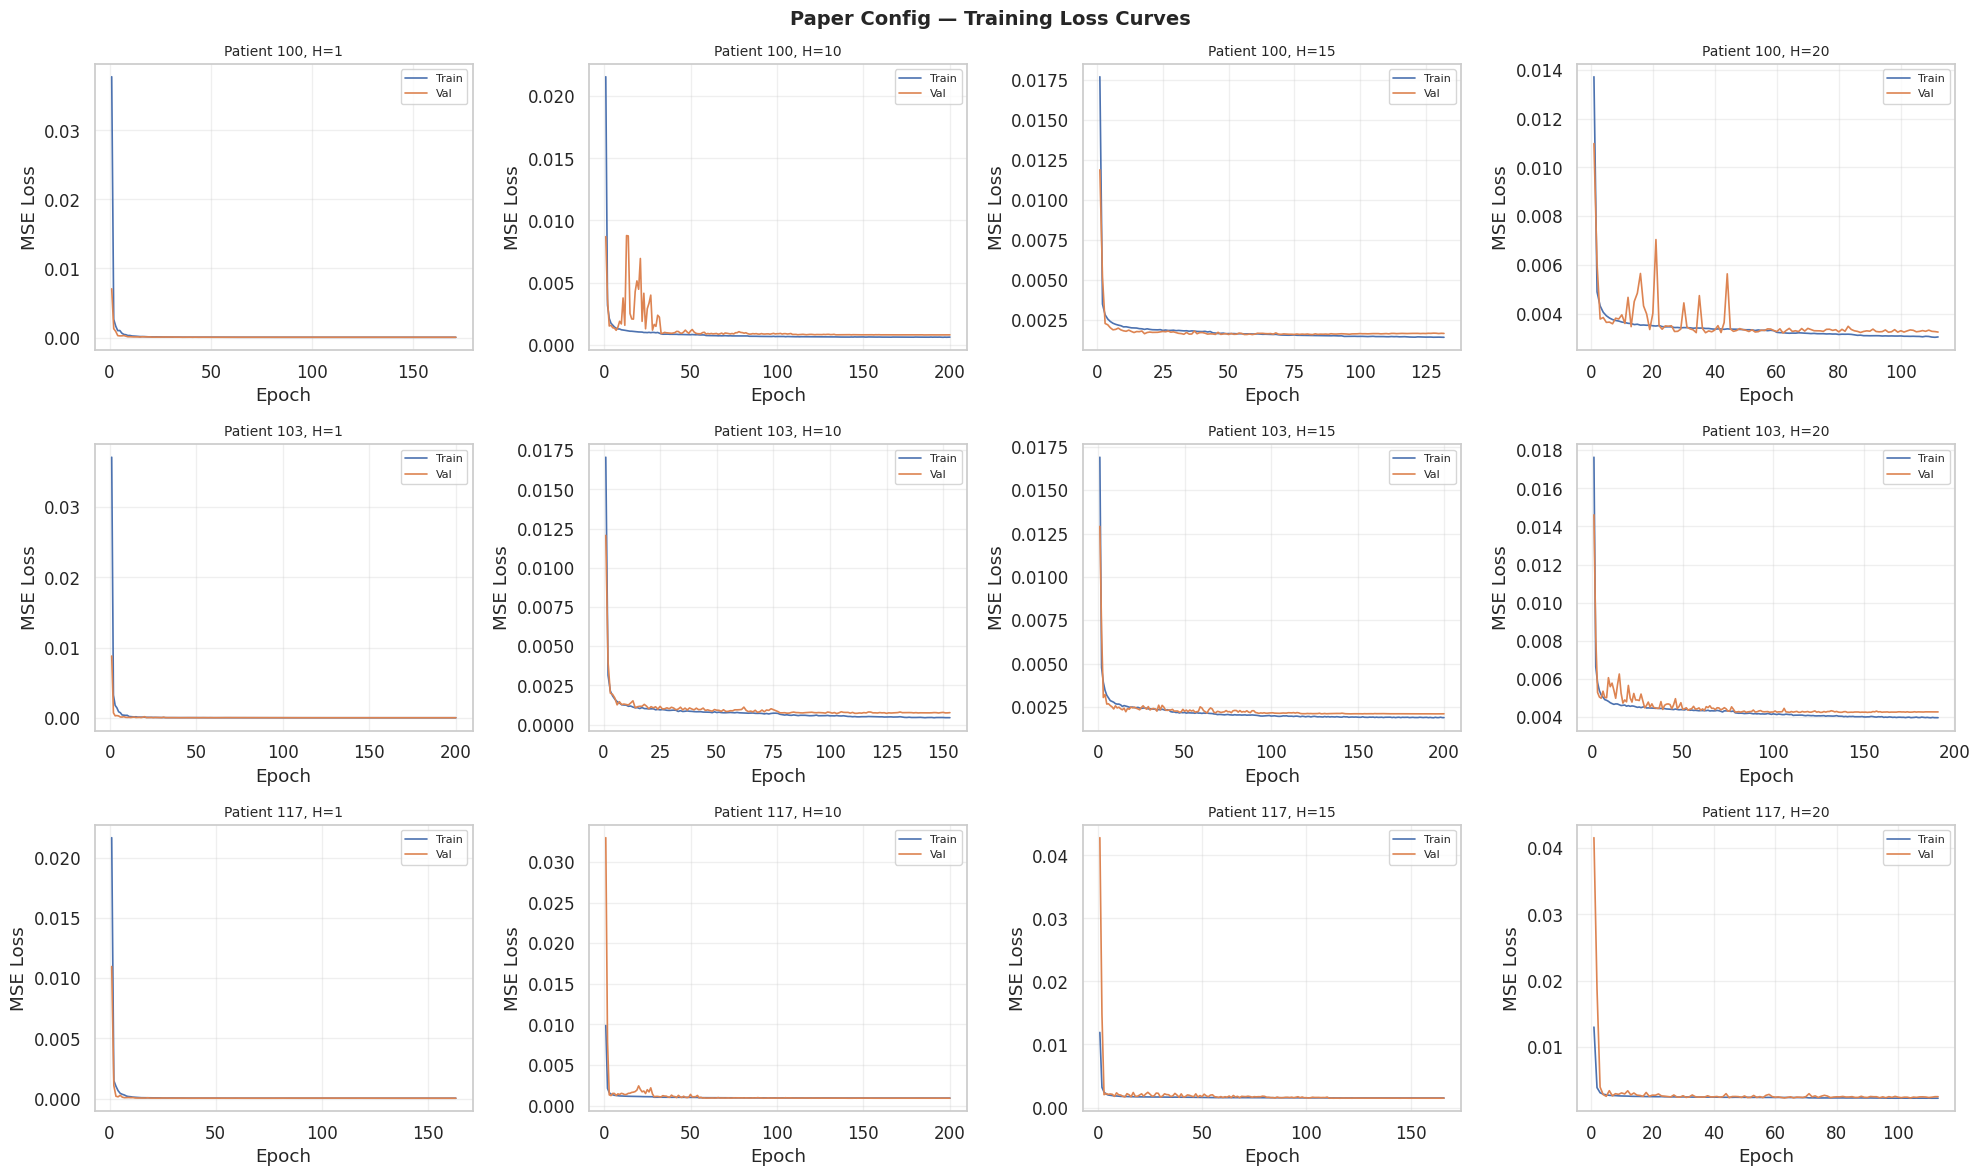

In [17]:
LOSS_VIZ_PATIENTS = ['100', '103', '117']

fig, axes = plt.subplots(len(LOSS_VIZ_PATIENTS), len(HORIZONS),
                         figsize=(5 * len(HORIZONS), 4 * len(LOSS_VIZ_PATIENTS)))

for row, rid in enumerate(LOSS_VIZ_PATIENTS):
    for col, horizon in enumerate(HORIZONS):
        ax = axes[row, col]
        key = (rid, horizon)
        if key not in training_histories:
            continue
        hist = training_histories[key]
        epochs_ran = range(1, len(hist['loss']) + 1)
        ax.plot(epochs_ran, hist['loss'], label='Train', linewidth=1.2)
        ax.plot(epochs_ran, hist['val_loss'], label='Val', linewidth=1.2)
        ax.set_title(f'Patient {rid}, H={horizon}', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

fig.suptitle(f'{CONFIG_NAME} Config — Training Loss Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.9 — Error Distribution Histograms

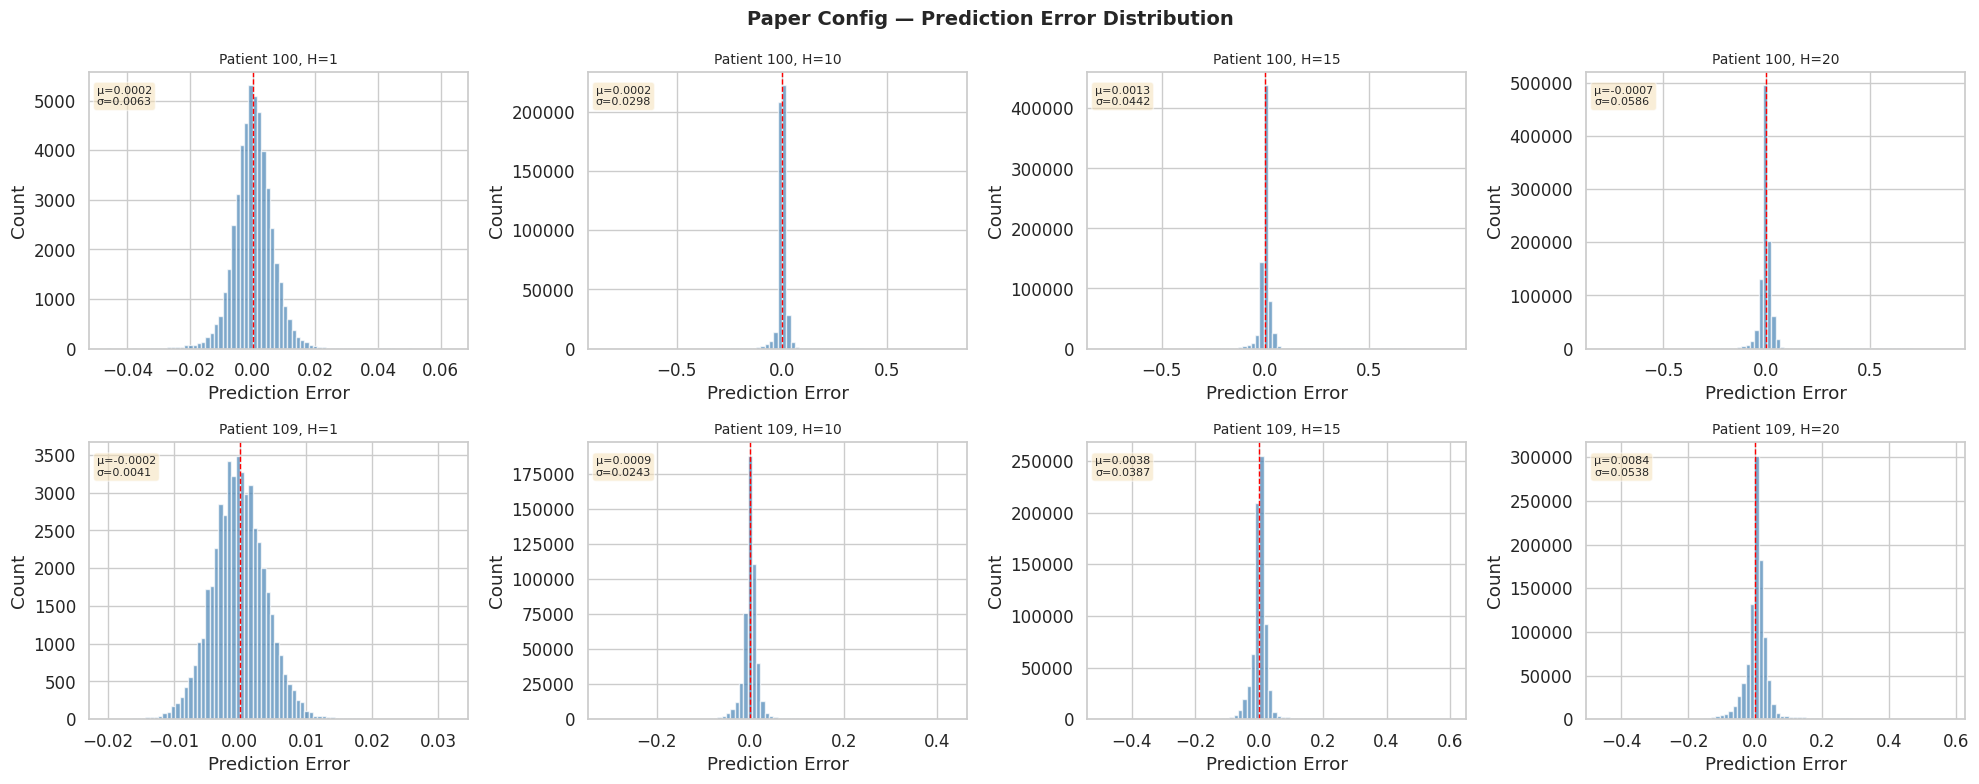

In [18]:
ERR_VIZ_PATIENTS = ['100', '109']

fig, axes = plt.subplots(len(ERR_VIZ_PATIENTS), len(HORIZONS),
                         figsize=(5 * len(HORIZONS), 4 * len(ERR_VIZ_PATIENTS)))

for row, rid in enumerate(ERR_VIZ_PATIENTS):
    for col, horizon in enumerate(HORIZONS):
        ax = axes[row, col]
        key = (rid, horizon)
        if key not in saved_preds:
            continue
        y_te, preds = saved_preds[key]
        errors = (y_te - preds).flatten()
        ax.hist(errors, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
        ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f'Patient {rid}, H={horizon}', fontsize=10)
        ax.set_xlabel('Prediction Error')
        ax.set_ylabel('Count')
        ax.text(0.02, 0.95, f'μ={errors.mean():.4f}\nσ={errors.std():.4f}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(f'{CONFIG_NAME} Config — Prediction Error Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.10 — Patient Ranking: R² per Horizon

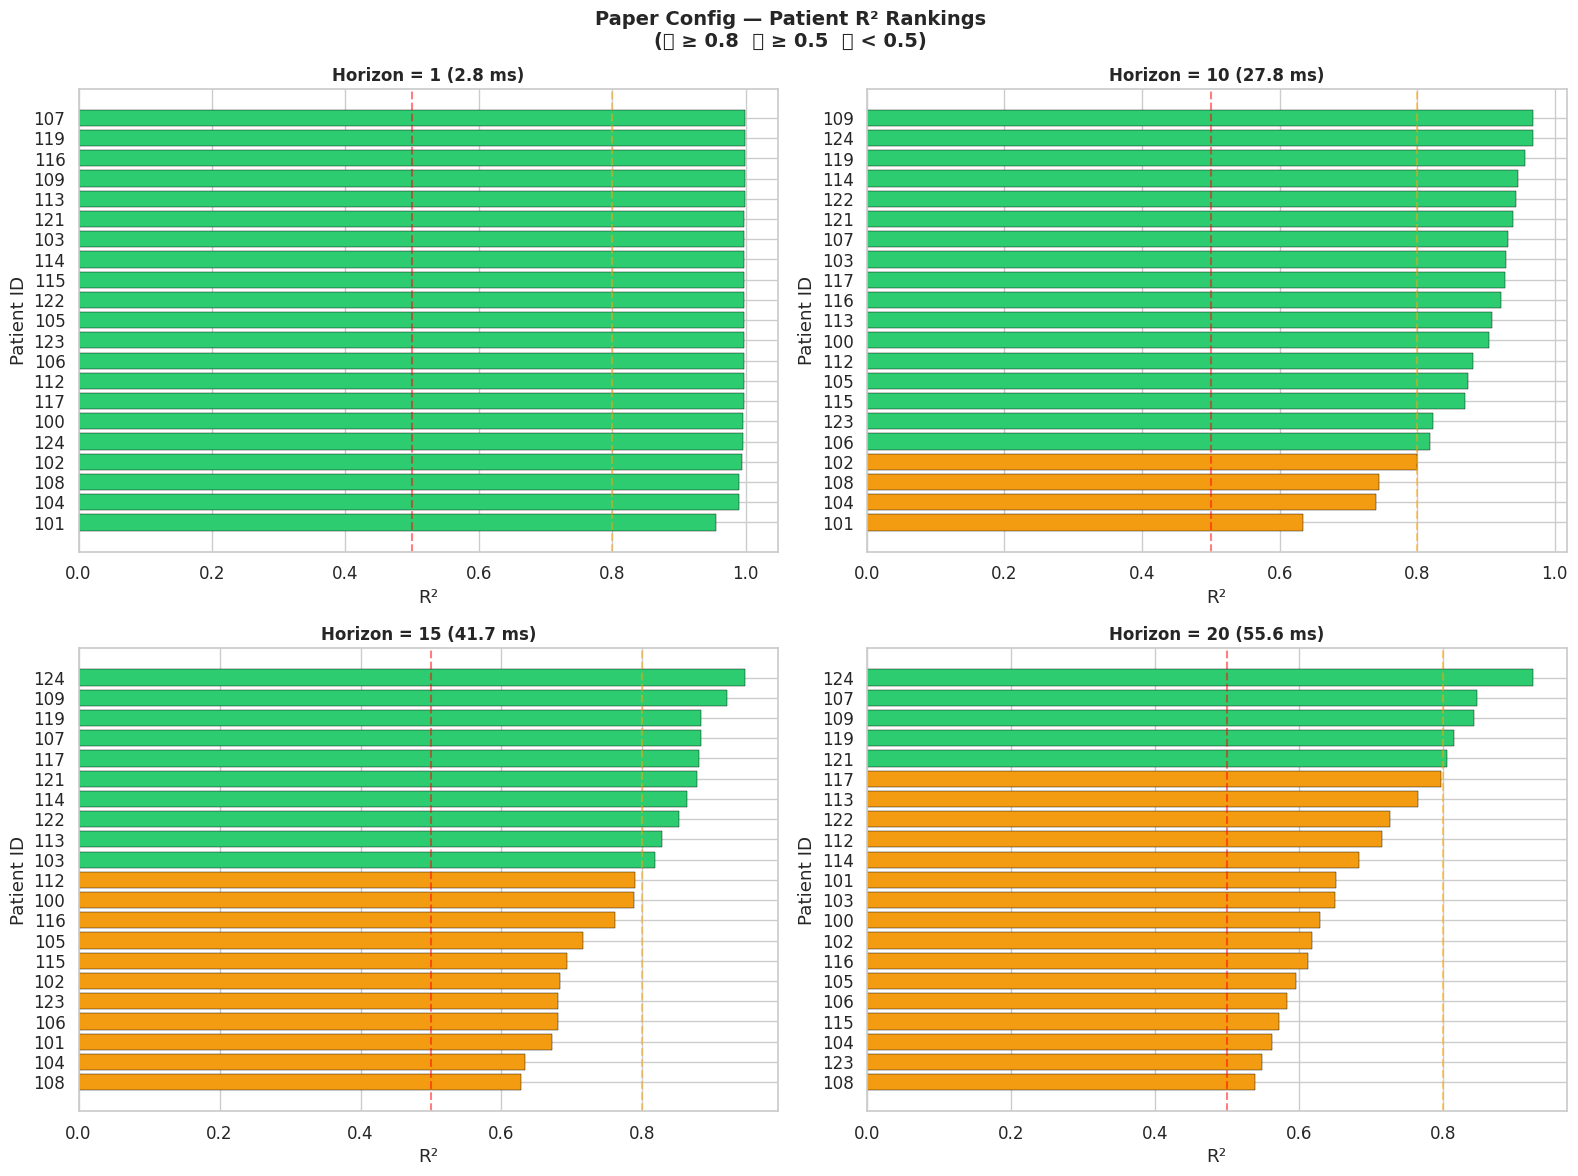

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, horizon in zip(axes.flatten(), HORIZONS):
    df_h = df_results[df_results['Horizon'] == horizon].sort_values('R2', ascending=True)
    colors = ['#e74c3c' if r2 < 0.5 else '#f39c12' if r2 < 0.8 else '#2ecc71'
              for r2 in df_h['R2']]
    ax.barh(df_h['Patient'], df_h['R2'], color=colors, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Horizon = {horizon} ({horizon/FS*1000:.1f} ms)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('R²')
    ax.set_ylabel('Patient ID')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
    ax.axvline(x=0.8, color='orange', linestyle='--', alpha=0.5)
    ax.set_xlim(left=min(0, df_h['R2'].min() - 0.05))

fig.suptitle(f'{CONFIG_NAME} Config — Patient R² Rankings\n'
             '(🟢 ≥ 0.8  🟡 ≥ 0.5  🔴 < 0.5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/patient_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.11 — Scatter: RMSE vs R²

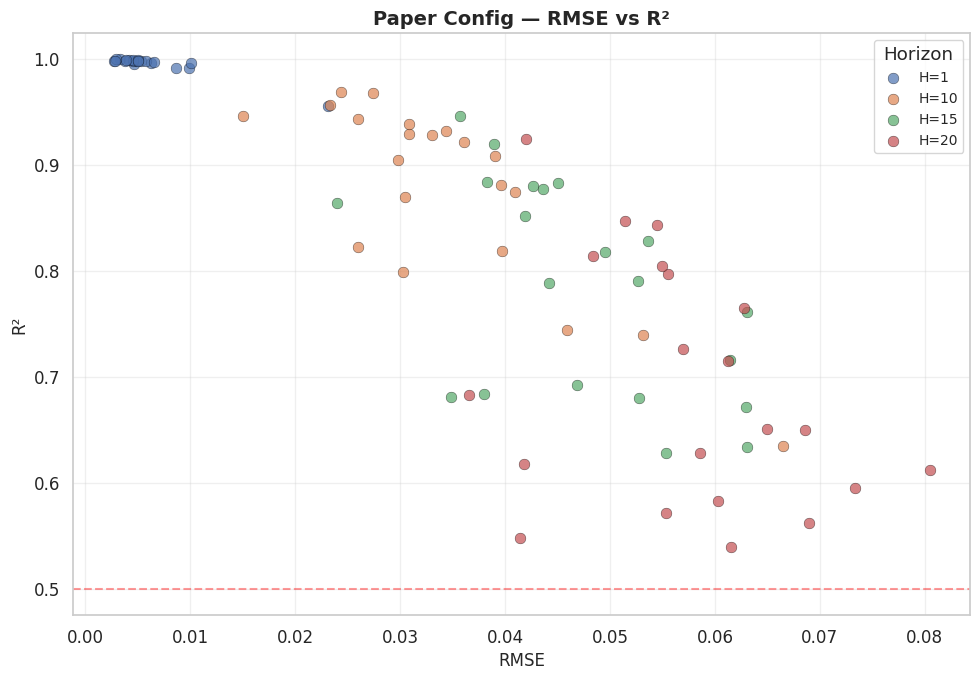

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

for horizon in HORIZONS:
    df_h = df_results[df_results['Horizon'] == horizon]
    ax.scatter(df_h['RMSE'], df_h['R2'], s=60, alpha=0.7,
               label=f'H={horizon}', edgecolors='black', linewidth=0.3)

ax.set_xlabel('RMSE', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title(f'{CONFIG_NAME} Config — RMSE vs R²', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
ax.legend(title='Horizon', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/scatter_rmse_vs_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.13 — Radar Chart

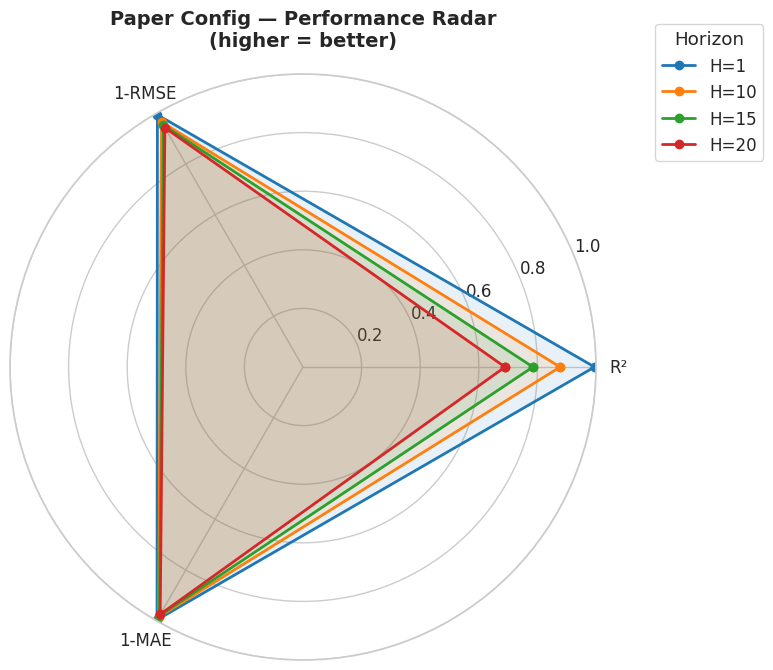

In [22]:
from math import pi

categories = ['R²', '1-RMSE', '1-MAE']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette('tab10', len(HORIZONS))

for idx, horizon in enumerate(HORIZONS):
    df_h = df_results[df_results['Horizon'] == horizon]
    values = [max(0, df_h['R2'].mean()), max(0, 1 - df_h['RMSE'].mean()), max(0, 1 - df_h['MAE'].mean())]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'H={horizon}', color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title(f'{CONFIG_NAME} Config — Performance Radar\n(higher = better)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Horizon')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Summary

In [23]:
print('\n' + '=' * 80)
print(f'EXPERIMENT COMPLETE — {CONFIG_NAME} CONFIG')
print('=' * 80)
print(f'Strategy         : Multi-Output (MIMO)')
print(f'Patients         : {len(PATIENTS)} (all MIT-BIH excl. 111 & 118)')
print(f'Horizons         : {HORIZONS}')
print(f'Total experiments: {len(df_results)}')
print(f'TCN blocks       : {NUM_BLOCKS}')
print(f'TCN filters      : {NUM_FILTERS}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Epochs           : {EPOCHS}')
print(f'Patience         : {PATIENCE}')
print(f'Results CSV      : {CSV_NAME}')
print(f'Plots directory  : {PLOT_DIR}/')
print()
print('Horizon interpretations (at 360 Hz):')
for h in HORIZONS:
    ms = h / FS * 1000
    print(f'  H={h:2d} → {ms:6.1f} ms')
print()
print('Mean R² per horizon:')
best = df_results.groupby('Horizon')['R2'].mean().sort_values(ascending=False)
for h, r2 in best.items():
    print(f'  H={h:2d} : R² = {r2:.4f}')
print()
print('Plots generated:')
for f in sorted(os.listdir(PLOT_DIR)):
    if f.endswith('.png'):
        print(f'  📊 {PLOT_DIR}/{f}')


EXPERIMENT COMPLETE — Paper CONFIG
Strategy         : Multi-Output (MIMO)
Patients         : 21 (all MIT-BIH excl. 111 & 118)
Horizons         : [1, 10, 15, 20]
Total experiments: 84
TCN blocks       : 1
TCN filters      : 256
Batch size       : 128
Epochs           : 200
Patience         : 50
Results CSV      : tcn_mo_paper_config_results.csv
Plots directory  : plots_paper/

Horizon interpretations (at 360 Hz):
  H= 1 →    2.8 ms
  H=10 →   27.8 ms
  H=15 →   41.7 ms
  H=20 →   55.6 ms

Mean R² per horizon:
  H= 1 : R² = 0.9952
  H=10 : R² = 0.8776
  H=15 : R² = 0.7847
  H=20 : R² = 0.6894

Plots generated:
  📊 plots_paper/barchart_mean_metrics.png
  📊 plots_paper/boxplots_metrics.png
  📊 plots_paper/error_distributions.png
  📊 plots_paper/heatmap_r2.png
  📊 plots_paper/heatmap_rmse.png
  📊 plots_paper/patient_ranking.png
  📊 plots_paper/per_step_r2_overlay.png
  📊 plots_paper/per_step_rmse.png
  📊 plots_paper/pred_100_MO_H1.png
  📊 plots_paper/pred_100_MO_H10.png
  📊 plots_paper/pre